<a href="https://colab.research.google.com/github/bharath-hue/TASK_TNS_AIML/blob/main/Outliers_detection_in_heights_and_weights_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("weight-height.csv")

Saving weight-height.csv to weight-height (1).csv


In [ ]:

df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [ ]:
df.describe()

,Height,Weight
count,10000.000000,10000.000000
mean,66.367560,161.440357
std,3.847528,32.108439
min,54.263133,64.700127
25%,63.505620,135.818051
50%,66.318070,161.212928
75%,69.174262,187.169525
max,78.998742,269.989699


## (1) Histograms

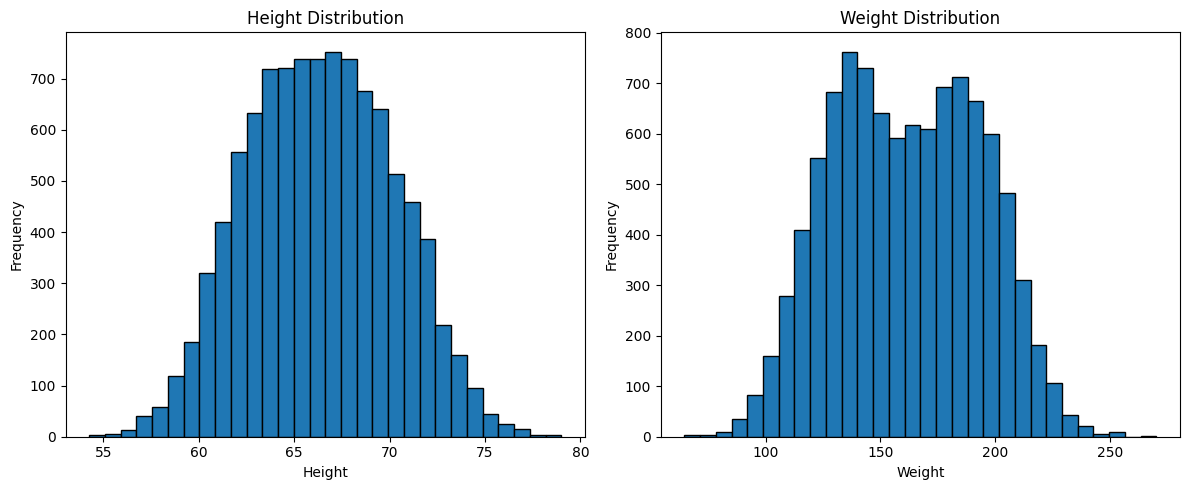

In [ ]:

# Histogram for Height
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(df['Height'], bins=30, edgecolor='black')
plt.title("Height Distribution")
plt.xlabel("Height")
plt.ylabel("Frequency")

# Histogram for Weight
plt.subplot(1,2,2)
plt.hist(df['Weight'], bins=30, edgecolor='black')
plt.title("Weight Distribution")
plt.xlabel("Weight")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## (2) Using IQR to detect Weight Outliers

In [ ]:

Q1_weight = df['Weight'].quantile(0.25)
Q3_weight = df['Weight'].quantile(0.75)
IQR_weight = Q3_weight - Q1_weight

lower_weight = Q1_weight - 1.5 * IQR_weight
upper_weight = Q3_weight + 1.5 * IQR_weight

weight_outliers = df[(df['Weight'] < lower_weight) | (df['Weight'] > upper_weight)]

print("Weight Outliers:")
print(weight_outliers)

Weight Outliers:
     Gender     Height      Weight
2014   Male  78.998742  269.989699


## (3) Using IQR to detect Height Outliers

In [ ]:

Q1_height = df['Height'].quantile(0.25)
Q3_height = df['Height'].quantile(0.75)
IQR_height = Q3_height - Q1_height

lower_height = Q1_height - 1.5 * IQR_height
upper_height = Q3_height + 1.5 * IQR_height

height_outliers = df[(df['Height'] < lower_height) | (df['Height'] > upper_height)]

print("Height Outliers:")
print(height_outliers)

Height Outliers:
      Gender     Height      Weight
994     Male  78.095867  255.690835
1317    Male  78.462053  227.342565
2014    Male  78.998742  269.989699
3285    Male  78.528210  253.889004
3757    Male  78.621374  245.733783
6624  Female  54.616858   71.393749
7294  Female  54.873728   78.606670
9285  Female  54.263133   64.700127


## (4) Replace Outliers with Mean and Median

In [ ]:

# Replace with Mean
df_mean = df.copy()

df_mean.loc[(df_mean['Weight'] < lower_weight) | (df_mean['Weight'] > upper_weight), 'Weight'] = df_mean['Weight'].mean()
df_mean.loc[(df_mean['Height'] < lower_height) | (df_mean['Height'] > upper_height), 'Height'] = df_mean['Height'].mean()

print("Dataset after replacing outliers with Mean:")
print(df_mean)

# Replace with Median
df_median = df.copy()

df_median.loc[(df_median['Weight'] < lower_weight) | (df_median['Weight'] > upper_weight), 'Weight'] = df_median['Weight'].median()
df_median.loc[(df_median['Height'] < lower_height) | (df_median['Height'] > upper_height), 'Height'] = df_median['Height'].median()

print("\nDataset after replacing outliers with Median:")
print(df_median)

Dataset after replacing outliers with Mean:
      Gender     Height      Weight
0       Male  73.847017  241.893563
1       Male  68.781904  162.310473
2       Male  74.110105  212.740856
3       Male  71.730978  220.042470
4       Male  69.881796  206.349801
...      ...        ...         ...
9995  Female  66.172652  136.777454
9996  Female  67.067155  170.867906
9997  Female  63.867992  128.475319
9998  Female  69.034243  163.852461
9999  Female  61.944246  113.649103

[10000 rows x 3 columns]

Dataset after replacing outliers with Median:
      Gender     Height      Weight
0       Male  73.847017  241.893563
1       Male  68.781904  162.310473
2       Male  74.110105  212.740856
3       Male  71.730978  220.042470
4       Male  69.881796  206.349801
...      ...        ...         ...
9995  Female  66.172652  136.777454
9996  Female  67.067155  170.867906
9997  Female  63.867992  128.475319
9998  Female  69.034243  163.852461
9999  Female  61.944246  113.649103

[10000 rows x 3 co